# Head Retraining with Language-Stratified Evaluation

**Changes from baseline:**
- Input LayerNorm on the 1024-dim embedding (approximates standardization)
- Reduced dropout (0.1 instead of 0.35)
- Language filtering: train and evaluate on English speakers only OR Chinese speakers only

**Flag:** Set `LANGUAGE = "english"` or `LANGUAGE = "chinese"` to select.

**Architecture:** frozen wav2vec2 → mean pool → **LayerNorm(1024)** → Linear(1024→256) → LayerNorm → GELU → Dropout(0.1) → Linear(256→128) → GELU → Dropout(0.1) → Linear(128→5)


In [1]:
!pip install -q soundfile librosa resampy transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.3 MB/s eta 0:00:00


In [2]:
import os
import json
import warnings
import random
from pathlib import Path
from typing import List, Dict, Tuple, Any

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
from tqdm import tqdm

from transformers import AutoFeatureExtractor, AutoModelForAudioClassification, get_cosine_schedule_with_warmup
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: NVIDIA H100 80GB HBM3


## 1. Mount Drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Configuration


In [4]:
# ============================================================
# LANGUAGE FLAG — change this to switch between languages
# Options: "english", "chinese", "all"
# ============================================================
LANGUAGE = "all"
# ============================================================

# ---- Paths ----
ESD_GT_CSV = Path("/content/drive/MyDrive/ESD/ESD_GT_Colabo.csv")
ESD_ZIP_PATH = Path("/content/drive/MyDrive/ESD_ZIP.zip")
ESD_AUDIO_ROOT = Path("/content/drive/MyDrive/ESD")

LOCAL_CACHE_ESD = Path("/content/audio_cache_esd")

OUT_DIR = Path(f"/content/drive/MyDrive/head_retrain_{LANGUAGE}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Model ----
MODEL_ID = "ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition"
TARGET_SR = 16_000

# ---- Emotions ----
SHARED_EMOTIONS = sorted(["angry", "happy", "neutral", "sad", "surprised"])

# ---- Training ----
BATCH_SIZE = 32
CHUNK_ROWS = 200
NUM_EPOCHS = 15
LR = 3e-4
WEIGHT_DECAY = 1e-2
WARMUP_FRAC = 0.10
MAX_GRAD_NORM = 1.0
LABEL_SMOOTH = 0.05
PATIENCE = 4

# ---- Head architecture (updated) ----
PROJ_DIM = 256
HIDDEN_DIM = 128
DROPOUT = 0.1  # Reduced from 0.35

# ---- CV ----
N_FOLDS = 5
BALANCE_CLASSES = True

print(f"LANGUAGE: {LANGUAGE}")
print(f"DROPOUT: {DROPOUT}")
print(f"Output: {OUT_DIR}")


LANGUAGE: all
DROPOUT: 0.1
Output: /content/drive/MyDrive/head_retrain_all


## 3. Extract ESD audio to local cache


In [5]:
import subprocess

LOCAL_CACHE_ESD.mkdir(exist_ok=True)
existing = list(LOCAL_CACHE_ESD.rglob("*.wav"))
if len(existing) > 1000:
    print(f"ESD cache: {len(existing)} files (already populated)")
else:
    if ESD_ZIP_PATH.exists():
        print("Extracting ESD from ZIP...")
        subprocess.run(['unzip', '-q', '-o', str(ESD_ZIP_PATH), '-d', str(LOCAL_CACHE_ESD)],
                       capture_output=True, text=True, check=True)
        print(f"Extracted {len(list(LOCAL_CACHE_ESD.rglob('*.wav')))} files")
    else:
        print("No ZIP, reading from Drive")
        LOCAL_CACHE_ESD = ESD_AUDIO_ROOT

print(f"Cache: {LOCAL_CACHE_ESD}")


Extracting ESD from ZIP...
Extracted 35000 files
Cache: /content/audio_cache_esd


## 4. Load GT and apply language filter


In [6]:
esd_path_map = {f.name: str(f) for f in LOCAL_CACHE_ESD.rglob("*.wav")}
print(f"Path map: {len(esd_path_map)} files")


Path map: 35000 files


In [7]:
esd_df = pd.read_csv(ESD_GT_CSV, sep=";")
print(f"GT columns: {list(esd_df.columns)}")
print(f"GT rows: {len(esd_df)}")

esd_df["emotion"] = esd_df["emotion"].astype(str).str.strip().str.lower()
esd_df["emotion"] = esd_df["emotion"].replace({"surprise": "surprised"})

# Speaker
if "speaker" in esd_df.columns:
    esd_df["speaker"] = esd_df["speaker"].astype(str).str.strip()
elif "speaker_id" in esd_df.columns:
    esd_df["speaker"] = esd_df["speaker_id"].astype(str).str.strip()

# Language
if "language" in esd_df.columns:
    esd_df["language"] = esd_df["language"].astype(str).str.strip().str.lower()
else:
    print("WARNING: no 'language' column — attempting to infer from speaker ID")
    # ESD convention: speakers 0001-0010 = English, 0011-0020 = Chinese
    def infer_language(spk):
        try:
            spk_num = int(spk)
            return "english" if spk_num <= 10 else "chinese"
        except:
            return "unknown"
    esd_df["language"] = esd_df["speaker"].apply(infer_language)

# Resolve local paths
if "filename" in esd_df.columns:
    esd_df["local_path"] = esd_df["filename"].astype(str).str.strip().map(esd_path_map)
elif "full_path" in esd_df.columns:
    esd_df["local_path"] = esd_df["full_path"].apply(
        lambda p: esd_path_map.get(os.path.basename(str(p).strip()), ""))

# Filter emotions + existing files
esd_df = esd_df[esd_df["emotion"].isin(SHARED_EMOTIONS)].copy()
esd_df = esd_df[esd_df["local_path"].notna() & (esd_df["local_path"] != "")].copy()
esd_df = esd_df[esd_df["local_path"].apply(lambda p: os.path.exists(str(p)))].copy()

print(f"\nBefore language filter:")
print(f"  Total: {len(esd_df)}")
print(f"  Languages: {esd_df['language'].value_counts().to_dict()}")
print(f"  Speakers: {sorted(esd_df['speaker'].unique())}")


GT columns: ['gender', 'speaker', 'emotion', 'filename', 'full_path', 'language']
GT rows: 35000

Before language filter:
  Total: 34994
  Languages: {'chinese': 17500, 'english': 17494}
  Speakers: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '3', '4', '5', '6', '7', '8', '9']


In [8]:
# ---- Apply language filter ----
if LANGUAGE != "all":
    esd_df = esd_df[esd_df["language"] == LANGUAGE].copy()

esd_df = esd_df.reset_index(drop=True)

print(f"After language filter (LANGUAGE='{LANGUAGE}'):")
print(f"  Samples: {len(esd_df)}")
print(f"  Speakers: {sorted(esd_df['speaker'].unique())}")
print(f"  N speakers: {esd_df['speaker'].nunique()}")
print(f"  Emotions:")
print(esd_df["emotion"].value_counts())

if len(esd_df) == 0:
    raise RuntimeError(f"No samples after filtering for language='{LANGUAGE}'!")


After language filter (LANGUAGE='all'):
  Samples: 34994
  Speakers: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '3', '4', '5', '6', '7', '8', '9']
  N speakers: 20
  Emotions:
emotion
neutral      7000
surprised    6999
happy        6999
angry        6998
sad          6998
Name: count, dtype: int64


## 5. Audio helpers


In [9]:
def load_audio_mono_resample(path: str, target_sr: int = TARGET_SR) -> np.ndarray:
    wav, sr = sf.read(path, dtype='float32')
    if wav.size == 0:
        raise RuntimeError(f"Empty audio: {path}")
    if len(wav.shape) > 1:
        wav = wav.mean(axis=1)
    if sr != target_sr:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=target_sr, res_type='soxr_hq')
    return wav

def chunk_rows(rows, n):
    for i in range(0, len(rows), n):
        yield rows[i:i+n]

def load_audio_batch_sequential(paths):
    results, valid_indices = [], []
    for i, p in enumerate(paths):
        try:
            results.append(torch.from_numpy(load_audio_mono_resample(p)).float())
            valid_indices.append(i)
        except:
            pass
    return results, valid_indices

test_wav = load_audio_mono_resample(esd_df["local_path"].iloc[0])
print(f"Audio OK: shape={test_wav.shape}")


Audio OK: shape=(48992,)


## 6. Model architecture

Key change: **Input LayerNorm** on the raw 1024-dim embedding before the
projection. This approximates the global standardization that makes the
linear probe achieve 77.77%, without requiring precomputed statistics.


In [10]:
class LNMLPHead(nn.Module):
    """
    InputLayerNorm -> Linear(1024->256) -> LayerNorm -> GELU -> Dropout
    -> Linear(256->128) -> GELU -> Dropout -> Linear(128->num_labels)

    The input LayerNorm normalizes the raw encoder output, approximating
    the standardization used by the linear probes.
    """
    def __init__(self, in_features: int, num_labels: int,
                 proj_dim: int = 256, hidden_dim: int = 128, dropout: float = 0.1):
        super().__init__()
        self.input_ln = nn.LayerNorm(in_features)  # NEW: normalize raw embeddings
        self.proj = nn.Linear(in_features, proj_dim)
        self.ln = nn.LayerNorm(proj_dim)
        self.mlp = nn.Sequential(
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(proj_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_labels),
        )
        nn.init.xavier_uniform_(self.proj.weight)
        nn.init.zeros_(self.proj.bias)
        for m in self.mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.input_ln(x)  # Normalize raw embeddings
        x = self.proj(x)
        x = self.ln(x)
        return self.mlp(x)


class HeadOnlyModel(nn.Module):
    """Frozen backbone + trainable head."""
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head
        for p in self.backbone.parameters():
            p.requires_grad = False

    def forward(self, **inputs):
        with torch.no_grad():
            hidden = self.backbone(**inputs).last_hidden_state
            embeddings = hidden.mean(dim=1)
        return self.head(embeddings)

print("Architecture defined")
print(f"  Input LayerNorm: YES")
print(f"  Dropout: {DROPOUT}")


Architecture defined
  Input LayerNorm: YES
  Dropout: 0.1


## 7. Labels & speaker splits


In [11]:
labels_sorted = SHARED_EMOTIONS
label2id = {lab: i for i, lab in enumerate(labels_sorted)}
id2label = {i: lab for lab, i in label2id.items()}
num_labels = len(labels_sorted)

esd_df["y"] = esd_df["emotion"].map(label2id).astype(int)

speakers = sorted(esd_df["speaker"].unique().tolist())
random.shuffle(speakers)

def split_speakers_kfold(speakers, k):
    folds = [[] for _ in range(k)]
    for i, spk in enumerate(speakers):
        folds[i % k].append(spk)
    splits = []
    for i in range(k):
        val_spk = sorted(folds[i])
        train_spk = [s for s in speakers if s not in set(val_spk)]
        splits.append((train_spk, val_spk))
    return splits

splits = split_speakers_kfold(speakers, N_FOLDS)
print(f"Labels: {label2id}")
print(f"Speakers ({len(speakers)}): {speakers}")
print(f"Folds: {N_FOLDS}")
for i, (tr, va) in enumerate(splits):
    n_tr = len(esd_df[esd_df["speaker"].isin(tr)])
    n_va = len(esd_df[esd_df["speaker"].isin(va)])
    print(f"  Fold {i+1}: train {len(tr)} spk ({n_tr}), val {len(va)} spk ({n_va})")



def split_speakers_kfold_stratified(esd_df, k):
    """Each fold gets equal English and Chinese speakers in validation."""
    en_speakers = sorted(esd_df[esd_df["language"] == "english"]["speaker"].unique().tolist())
    zh_speakers = sorted(esd_df[esd_df["language"] == "chinese"]["speaker"].unique().tolist())

    random.shuffle(en_speakers)
    random.shuffle(zh_speakers)

    # Assign to folds round-robin within each language
    en_folds = [[] for _ in range(k)]
    zh_folds = [[] for _ in range(k)]
    for i, spk in enumerate(en_speakers):
        en_folds[i % k].append(spk)
    for i, spk in enumerate(zh_speakers):
        zh_folds[i % k].append(spk)

    splits = []
    for i in range(k):
        val_spk = sorted(en_folds[i] + zh_folds[i])
        train_spk = [s for s in en_speakers + zh_speakers if s not in set(val_spk)]
        splits.append((train_spk, val_spk))

    return splits


splits = split_speakers_kfold_stratified(esd_df, N_FOLDS)


Labels: {'angry': 0, 'happy': 1, 'neutral': 2, 'sad': 3, 'surprised': 4}
Speakers (20): ['9', '14', '4', '13', '18', '3', '5', '8', '15', '20', '7', '19', '10', '2', '11', '6', '16', '17', '1', '12']
Folds: 5
  Fold 1: train 16 spk (27994), val 4 spk (7000)
  Fold 2: train 16 spk (27994), val 4 spk (7000)
  Fold 3: train 16 spk (27994), val 4 spk (7000)
  Fold 4: train 16 spk (27994), val 4 spk (7000)
  Fold 5: train 16 spk (28000), val 4 spk (6994)


## 8. Forward & evaluation


In [12]:
extractor = AutoFeatureExtractor.from_pretrained(MODEL_ID)

def forward_batch(model, waveforms, labels):
    inputs = extractor(
        [w.numpy() for w in waveforms],
        sampling_rate=TARGET_SR,
        return_tensors="pt",
        padding=True,
    )
    inputs = {k: v.to(device, non_blocking=True) for k, v in inputs.items()}
    y = torch.tensor(labels, dtype=torch.long, device=device)
    logits = model(**inputs)
    return logits, y


@torch.inference_mode()
def evaluate(model, rows, criterion):
    model.eval()
    total, correct, total_loss = 0, 0, 0.0
    all_true, all_pred = [], []
    buffer_wavs, buffer_y = [], []

    for chunk in chunk_rows(rows, CHUNK_ROWS):
        paths = [p for p, _ in chunk]
        labels = [y for _, y in chunk]
        wavs, valid_idx = load_audio_batch_sequential(paths)
        valid_labels = [labels[i] for i in valid_idx]

        for w, y in zip(wavs, valid_labels):
            buffer_wavs.append(w)
            buffer_y.append(int(y))

            if len(buffer_wavs) >= BATCH_SIZE:
                logits, y_t = forward_batch(model, buffer_wavs, buffer_y)
                loss = criterion(logits, y_t)
                preds = torch.argmax(logits, dim=-1)
                total_loss += loss.item() * len(buffer_wavs)
                correct += (preds == y_t).sum().item()
                total += len(buffer_wavs)
                all_true.extend(y_t.cpu().tolist())
                all_pred.extend(preds.cpu().tolist())
                buffer_wavs, buffer_y = [], []

    if buffer_wavs:
        logits, y_t = forward_batch(model, buffer_wavs, buffer_y)
        loss = criterion(logits, y_t)
        preds = torch.argmax(logits, dim=-1)
        total_loss += loss.item() * len(buffer_wavs)
        correct += (preds == y_t).sum().item()
        total += len(buffer_wavs)
        all_true.extend(y_t.cpu().tolist())
        all_pred.extend(preds.cpu().tolist())

    if total == 0:
        return {"val_acc": 0, "val_loss": 0, "val_f1": 0, "val_prec": 0,
                "val_rec": 0, "y_true": [], "y_pred": [], "val_n": 0}

    return {
        "val_acc": correct / total,
        "val_loss": total_loss / total,
        "val_f1": f1_score(all_true, all_pred, average="macro", zero_division=0),
        "val_prec": precision_score(all_true, all_pred, average="macro", zero_division=0),
        "val_rec": recall_score(all_true, all_pred, average="macro", zero_division=0),
        "y_true": all_true, "y_pred": all_pred, "val_n": total,
    }

print("Helpers ready")


preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

Helpers ready


## 9. Training loop


In [13]:
fold_results = []

for fold_idx, (train_spk, val_spk) in enumerate(splits, start=1):
    print(f"\n{'='*60}")
    print(f"  Fold {fold_idx}/{N_FOLDS} | LANGUAGE={LANGUAGE}")
    print(f"  Train speakers: {train_spk}")
    print(f"  Val speakers:   {val_spk}")
    print(f"{'='*60}")

    train_df = esd_df[esd_df["speaker"].isin(train_spk)]
    val_df = esd_df[esd_df["speaker"].isin(val_spk)]
    train_rows = list(zip(train_df["local_path"].tolist(), train_df["y"].tolist()))
    val_rows = list(zip(val_df["local_path"].tolist(), val_df["y"].tolist()))
    print(f"  Train: {len(train_rows)}, Val: {len(val_rows)}")

    # Class balancing
    by_class = {}
    if BALANCE_CLASSES:
        for p, y in train_rows:
            by_class.setdefault(int(y), []).append((p, int(y)))
        for c in by_class:
            random.shuffle(by_class[c])

    # Build model
    base_model = AutoModelForAudioClassification.from_pretrained(MODEL_ID)
    backbone = base_model.wav2vec2
    embed_dim = base_model.config.hidden_size

    head = LNMLPHead(embed_dim, num_labels, PROJ_DIM, HIDDEN_DIM, DROPOUT)
    model = HeadOnlyModel(backbone, head)
    model.to(device)

    trainable_count = sum(p.numel() for p in head.parameters())
    print(f"  Trainable params: {trainable_count:,}")

    optimizer = torch.optim.AdamW(head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

    steps_per_epoch = max(1, len(train_rows) // BATCH_SIZE)
    total_steps = max(1, steps_per_epoch * NUM_EPOCHS)
    warmup_steps = max(1, int(WARMUP_FRAC * total_steps))
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    best_val_acc = -1.0
    best_val_metrics = {}
    no_improve = 0
    history = []

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        running_loss, total_samples, correct = 0.0, 0, 0

        if BALANCE_CLASSES:
            cls_keys = sorted(by_class.keys())
            max_len = max(len(by_class[c]) for c in cls_keys)
            epoch_rows = []
            for i in range(max_len):
                for c in cls_keys:
                    if i < len(by_class[c]):
                        epoch_rows.append(by_class[c][i])
            random.shuffle(epoch_rows)
        else:
            epoch_rows = train_rows[:]
            random.shuffle(epoch_rows)

        buffer_wavs, buffer_y = [], []

        for chunk in chunk_rows(epoch_rows, CHUNK_ROWS):
            paths = [p for p, _ in chunk]
            labels_chunk = [y for _, y in chunk]
            wavs, valid_idx = load_audio_batch_sequential(paths)
            valid_labels = [labels_chunk[i] for i in valid_idx]

            for w, y in zip(wavs, valid_labels):
                buffer_wavs.append(w)
                buffer_y.append(int(y))

                if len(buffer_wavs) >= BATCH_SIZE:
                    optimizer.zero_grad(set_to_none=True)
                    logits, y_t = forward_batch(model, buffer_wavs, buffer_y)
                    loss = criterion(logits, y_t)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(head.parameters(), MAX_GRAD_NORM)
                    optimizer.step()
                    scheduler.step()

                    bs = len(buffer_wavs)
                    running_loss += loss.item() * bs
                    preds = torch.argmax(logits, dim=-1)
                    correct += (preds == y_t).sum().item()
                    total_samples += bs
                    buffer_wavs, buffer_y = [], []

        # Flush
        if buffer_wavs:
            optimizer.zero_grad(set_to_none=True)
            logits, y_t = forward_batch(model, buffer_wavs, buffer_y)
            loss = criterion(logits, y_t)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(head.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            scheduler.step()

            bs = len(buffer_wavs)
            running_loss += loss.item() * bs
            preds = torch.argmax(logits, dim=-1)
            correct += (preds == y_t).sum().item()
            total_samples += bs

        if total_samples == 0:
            continue

        train_acc = correct / total_samples
        train_loss = running_loss / total_samples

        # Validation
        val_m = evaluate(model, val_rows, criterion)

        # Per-class recall
        if val_m["y_true"]:
            pcr = recall_score(val_m["y_true"], val_m["y_pred"],
                               labels=list(range(num_labels)), average=None, zero_division=0)
            cm = confusion_matrix(val_m["y_true"], val_m["y_pred"], labels=list(range(num_labels)))
        else:
            pcr = np.zeros(num_labels)
            cm = np.zeros((num_labels, num_labels))

        print(f"  Epoch {epoch}/{NUM_EPOCHS}: "
              f"train_acc={train_acc:.4f} loss={train_loss:.4f} | "
              f"val_acc={val_m['val_acc']:.4f} f1={val_m['val_f1']:.4f} "
              f"prec={val_m['val_prec']:.4f} rec={val_m['val_rec']:.4f} | "
              f"lr={optimizer.param_groups[0]['lr']:.2e}")
        print(f"    Recall: {dict(zip(labels_sorted, [f'{r:.3f}' for r in pcr]))}")

        history.append({
            "epoch": epoch,
            "train_acc": float(train_acc), "train_loss": float(train_loss),
            "val_acc": float(val_m["val_acc"]), "val_loss": float(val_m["val_loss"]),
            "val_f1": float(val_m["val_f1"]),
            "val_prec": float(val_m["val_prec"]), "val_rec": float(val_m["val_rec"]),
            "per_class_recall": {labels_sorted[i]: float(pcr[i]) for i in range(num_labels)},
            "confusion_matrix": cm.tolist(),
            "lr": float(optimizer.param_groups[0]["lr"]),
        })

        if val_m["val_acc"] > best_val_acc:
            best_val_acc = float(val_m["val_acc"])
            best_val_metrics = {
                "val_acc": val_m["val_acc"], "val_f1": val_m["val_f1"],
                "val_prec": val_m["val_prec"], "val_rec": val_m["val_rec"],
                "epoch": epoch, "confusion_matrix": cm.tolist(),
                "per_class_recall": {labels_sorted[i]: float(pcr[i]) for i in range(num_labels)},
            }
            no_improve = 0
            print(f"    >>> New best! val_acc={best_val_acc:.4f}")
        else:
            no_improve += 1
            print(f"    No improvement ({no_improve}/{PATIENCE})")
            if no_improve >= PATIENCE:
                print(f"    Early stopping at epoch {epoch}")
                break

    # Fold summary
    print(f"\n  Fold {fold_idx} SUMMARY:")
    print(f"    Best val_acc: {best_val_acc:.4f}")
    print(f"    Best val_f1:  {best_val_metrics.get('val_f1', 0):.4f}")
    print(f"    Best epoch:   {best_val_metrics.get('epoch', 0)}")
    print(f"    Epochs run:   {len(history)}")
    if best_val_metrics.get("per_class_recall"):
        print(f"    Best recall:  {best_val_metrics['per_class_recall']}")

    fold_results.append({
        "fold": fold_idx,
        "train_speakers": train_spk,
        "val_speakers": val_spk,
        "best_val_acc": best_val_acc,
        "best_val_f1": best_val_metrics.get("val_f1", 0),
        "best_val_prec": best_val_metrics.get("val_prec", 0),
        "best_val_rec": best_val_metrics.get("val_rec", 0),
        "best_epoch": best_val_metrics.get("epoch", 0),
        "best_cm": best_val_metrics.get("confusion_matrix", []),
        "best_per_class_recall": best_val_metrics.get("per_class_recall", {}),
        "epochs_trained": len(history),
        "history": history,
    })

    del model, backbone, optimizer, scheduler
    torch.cuda.empty_cache()

print("\nAll folds complete!")



  Fold 1/5 | LANGUAGE=all
  Train speakers: ['16', '11', '13', '15', '12', '17', '14', '19', '8', '3', '1', '2', '10', '4', '5', '6']
  Val speakers:   ['18', '20', '7', '9']
  Train: 28000, Val: 6994


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition
Key                      | Status     | 
-------------------------+------------+-
classifier.output.bias   | UNEXPECTED | 
classifier.dense.bias    | UNEXPECTED | 
classifier.dense.weight  | UNEXPECTED | 
classifier.output.weight | UNEXPECTED | 
classifier.bias          | MISSING    | 
projector.bias           | MISSING    | 
projector.weight         | MISSING    | 
classifier.weight        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Wav2Vec2ForSequenceClassification LOAD REPORT from: ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition
Key                      | Status     | 
-------------------------+------------+-
classifier.output.bias   | UNEXPECTED | 
classifier.dense.bias    | UNEXPECTED | 
classifier.dense.weight  | UNEXPECTED | 
classifier.output.weight | UNEXPECTED | 
classifier.bias          | MISSING    | 
projector.bias           | MISSING    | 
projector.weight         | MISSING    | 
classifier.weight        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable params: 298,501
  Epoch 1/15: train_acc=0.6530 loss=0.9554 | val_acc=0.6443 f1=0.6414 prec=0.6609 rec=0.6443 | lr=2.00e-04
    Recall: {'angry': '0.861', 'happy': '0.396', 'neutral': '0.734', 'sad': '0.652', 'surprised': '0.579'}
    >>> New best! val_acc=0.6443
  Epoch 2/15: train_acc=0.7533 loss=0.7634 | val_acc=0.6433 f1=0.6408 prec=0.6564 rec=0.6433 | lr=2.99e-04
    Recall: {'angry': '0.760', 'happy': '0.340', 'neutral': '0.660', 'sad': '0.694', 'surprised': '0.763'}
    No improvement (1/4)
  Epoch 3/15: train_acc=0.7867 loss=0.6933 | val_acc=0.6794 f1=0.6791 prec=0.6823 rec=0.6794 | lr=2.91e-04
    Recall: {'angry': '0.789', 'happy': '0.471', 'neutral': '0.715', 'sad': '0.729', 'surprised': '0.693'}
    >>> New best! val_acc=0.6794
  Epoch 4/15: train_acc=0.8007 loss=0.6646 | val_acc=0.6517 f1=0.6406 prec=0.6560 rec=0.6517 | lr=2.75e-04
    Recall: {'angry': '0.894', 'happy': '0.301', 'neutral': '0.718', 'sad': '0.674', 'surprised': '0.671'}
    No improvement (1/4)


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition
Key                      | Status     | 
-------------------------+------------+-
classifier.output.bias   | UNEXPECTED | 
classifier.dense.bias    | UNEXPECTED | 
classifier.dense.weight  | UNEXPECTED | 
classifier.output.weight | UNEXPECTED | 
classifier.bias          | MISSING    | 
projector.bias           | MISSING    | 
projector.weight         | MISSING    | 
classifier.weight        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable params: 298,501
  Epoch 1/15: train_acc=0.6305 loss=1.0091 | val_acc=0.7050 f1=0.6981 prec=0.7061 rec=0.7050 | lr=2.00e-04
    Recall: {'angry': '0.839', 'happy': '0.370', 'neutral': '0.784', 'sad': '0.846', 'surprised': '0.686'}
    >>> New best! val_acc=0.7050
  Epoch 2/15: train_acc=0.7435 loss=0.7867 | val_acc=0.7107 f1=0.7132 prec=0.7266 rec=0.7107 | lr=2.99e-04
    Recall: {'angry': '0.790', 'happy': '0.456', 'neutral': '0.832', 'sad': '0.763', 'surprised': '0.712'}
    >>> New best! val_acc=0.7107
  Epoch 3/15: train_acc=0.7735 loss=0.7264 | val_acc=0.7140 f1=0.7037 prec=0.7262 rec=0.7140 | lr=2.91e-04
    Recall: {'angry': '0.726', 'happy': '0.323', 'neutral': '0.928', 'sad': '0.790', 'surprised': '0.804'}
    >>> New best! val_acc=0.7140
  Epoch 4/15: train_acc=0.7880 loss=0.6914 | val_acc=0.7340 f1=0.7264 prec=0.7375 rec=0.7340 | lr=2.75e-04
    Recall: {'angry': '0.812', 'happy': '0.402', 'neutral': '0.949', 'sad': '0.796', 'surprised': '0.711'}
    >>> New best!

## 10. Summary


In [14]:
accs = [r["best_val_acc"] for r in fold_results]
f1s = [r["best_val_f1"] for r in fold_results]
precs = [r["best_val_prec"] for r in fold_results]
recs = [r["best_val_rec"] for r in fold_results]

print(f"{'='*70}")
print(f"  RESULTS — LANGUAGE={LANGUAGE}, DROPOUT={DROPOUT}, InputLayerNorm=YES")
print(f"{'='*70}")
print(f"  {'Fold':<6s} | {'Acc':>7s} | {'F1':>7s} | {'Prec':>7s} | {'Rec':>7s} | {'Epoch':>5s}")
print(f"  {'-'*6}-+-{'-'*7}-+-{'-'*7}-+-{'-'*7}-+-{'-'*7}-+-{'-'*5}")
for r in fold_results:
    print(f"  {r['fold']:<6d} | {r['best_val_acc']:>7.4f} | {r['best_val_f1']:>7.4f} | "
          f"{r['best_val_prec']:>7.4f} | {r['best_val_rec']:>7.4f} | {r['best_epoch']:>5d}")
print(f"  {'-'*6}-+-{'-'*7}-+-{'-'*7}-+-{'-'*7}-+-{'-'*7}-+-{'-'*5}")
print(f"  {'Mean':<6s} | {np.mean(accs):>7.4f} | {np.mean(f1s):>7.4f} | "
      f"{np.mean(precs):>7.4f} | {np.mean(recs):>7.4f} |")
print(f"  {'Std':<6s} | {np.std(accs):>7.4f} | {np.std(f1s):>7.4f} | "
      f"{np.std(precs):>7.4f} | {np.std(recs):>7.4f} |")
print(f"{'='*70}")

# Per-class recall aggregated
print(f"\nPer-class recall (mean across folds):")
for emo in labels_sorted:
    vals = [r["best_per_class_recall"].get(emo, 0) for r in fold_results]
    print(f"  {emo:<12s}: {np.mean(vals):.3f} +/- {np.std(vals):.3f}")

# Comparison with previous results
print(f"\nComparison:")
print(f"  Baseline (all languages, dropout=0.35, no input LN): 73.74%")
print(f"  This run ({LANGUAGE}, dropout={DROPOUT}, input LN):   {np.mean(accs)*100:.2f}%")


  RESULTS — LANGUAGE=all, DROPOUT=0.1, InputLayerNorm=YES
  Fold   |     Acc |      F1 |    Prec |     Rec | Epoch
  -------+---------+---------+---------+---------+------
  1      |  0.7911 |  0.7949 |  0.8186 |  0.7911 |    13
  2      |  0.7821 |  0.7831 |  0.8061 |  0.7821 |     5
  3      |  0.7281 |  0.7274 |  0.7670 |  0.7281 |     7
  4      |  0.6993 |  0.6934 |  0.6962 |  0.6993 |     9
  5      |  0.7551 |  0.7511 |  0.7632 |  0.7551 |    15
  -------+---------+---------+---------+---------+------
  Mean   |  0.7512 |  0.7500 |  0.7702 |  0.7512 |
  Std    |  0.0340 |  0.0370 |  0.0428 |  0.0340 |

Per-class recall (mean across folds):
  angry       : 0.782 +/- 0.078
  happy       : 0.603 +/- 0.149
  neutral     : 0.905 +/- 0.064
  sad         : 0.801 +/- 0.055
  surprised   : 0.665 +/- 0.132

Comparison:
  Baseline (all languages, dropout=0.35, no input LN): 73.74%
  This run (all, dropout=0.1, input LN):   75.12%


## 11. Save results


In [15]:
report = {
    "language": LANGUAGE,
    "dropout": DROPOUT,
    "input_layernorm": True,
    "n_folds": N_FOLDS,
    "num_epochs": NUM_EPOCHS,
    "mean_acc": float(np.mean(accs)),
    "std_acc": float(np.std(accs)),
    "mean_f1": float(np.mean(f1s)),
    "std_f1": float(np.std(f1s)),
    "per_fold": [{k: v for k, v in r.items() if k != "history"} for r in fold_results],
}

out_json = OUT_DIR / f"results_{LANGUAGE}.json"
with open(out_json, "w") as f:
    json.dump(report, f, indent=2, default=str)
print(f"Results saved to {out_json}")

# Save histories
for r in fold_results:
    h_path = OUT_DIR / f"history_fold{r['fold']}.json"
    with open(h_path, "w") as f:
        json.dump(r["history"], f, indent=2)
print(f"Histories saved to {OUT_DIR}")

print("\nDONE!")


Results saved to /content/drive/MyDrive/head_retrain_all/results_all.json
Histories saved to /content/drive/MyDrive/head_retrain_all

DONE!


## 12. Training curves


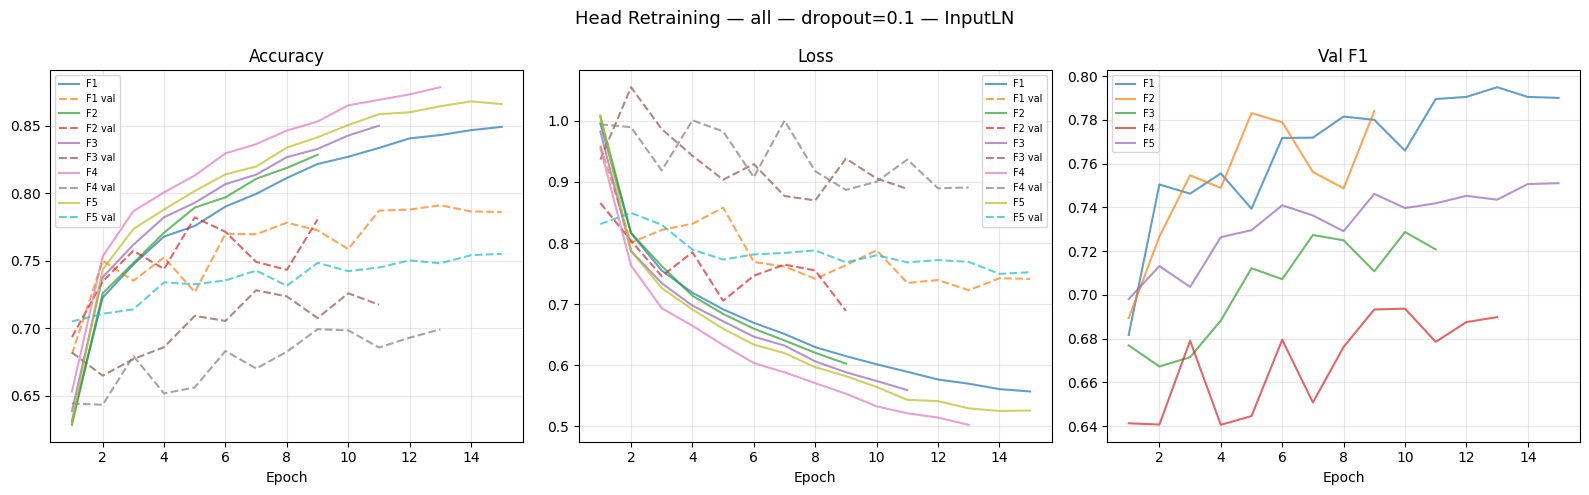

Curves saved to /content/drive/MyDrive/head_retrain_all


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Head Retraining — {LANGUAGE} — dropout={DROPOUT} — InputLN", fontsize=13)

for r in fold_results:
    f = r["fold"]
    h = r["history"]
    eps = [e["epoch"] for e in h]

    axes[0].plot(eps, [e["train_acc"] for e in h], label=f"F{f}", alpha=0.7)
    axes[0].plot(eps, [e["val_acc"] for e in h], '--', label=f"F{f} val", alpha=0.7)
    axes[0].set_title("Accuracy")

    axes[1].plot(eps, [e["train_loss"] for e in h], label=f"F{f}", alpha=0.7)
    axes[1].plot(eps, [e["val_loss"] for e in h], '--', label=f"F{f} val", alpha=0.7)
    axes[1].set_title("Loss")

    axes[2].plot(eps, [e["val_f1"] for e in h], label=f"F{f}", alpha=0.7)
    axes[2].set_title("Val F1")

for ax in axes:
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(str(OUT_DIR / f"curves_{LANGUAGE}.png"), dpi=150)
plt.show()
print(f"Curves saved to {OUT_DIR}")
